In [1]:
XLA_PYTHON_CLIENT_MEM_FRACTION=.9


import jax.numpy as jnp

import scipy.io as sio
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.sparse.linalg import eigsh
#%matplotlib inline
#import utils
import jax

import math
import os
from functools import partial
from jax import random


def gett_all(ijlm, A,B):
    i, j, l, m = list(ijlm)
    pexp = i+'a,'+j+'a,'+l+'b,'+m+'b->'
    qexp = i+'a,'+j+'a,'+l+'a,'+m+'a->'
    pval = jnp.einsum(pexp, A, B, A, B)
    pqval = pval - jnp.einsum(qexp, A, B, A, B)
    return pval,pqval

@partial(jax.jit, static_argnames=['P','Q'])
def getest_all0(Xs1,Xs2,P,Q,M=jnp.inf,F=jnp.inf):
    #P=jnp.shape(Xs1)[0]
    #Q=jnp.shape(Xs1)[1]
    #Xs1=Xs1_o-jnp.sum(Xs1_o,axis=0)/P
    #Xs2=Xs2_o-jnp.sum(Xs2_o,axis=0)/P

    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))/P
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))/Q
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=1)/Q ))/P
    Term3=-(1-Qhr)/Q * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=0)/P ))/Q
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.sum(jnp.power(Xs1*Xs2,2))/(P*Q)
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.sum(Xs1*Xs2)/(P*Q))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp
    
@partial(jax.jit, static_argnames=['P','Q'])
def getest_all(A,B,P,Q):
    nf = jnp.sqrt(P)*jnp.sqrt(Q)
    # Wrap *all* the following in a single shared_intermediates context
    #with shared_intermediates():
    t1,t1d = gett_all('ijji', A/nf, B/nf)
    t2,t2d = gett_all('iiii', A/nf, B/nf)
    t3,t3d = gett_all('ijjj', A/nf, B/nf)
    #t4,t4d = gett_all('iiij', A/nf)#<
    t5,t5d = gett_all('ijjl', A/nf, B/nf)
    t6,t6d = gett_all('iijj', A/nf, B/nf)
    t7,t7d = gett_all('iijl', A/nf, B/nf)
    #t8,t8d = gett_all('ijll', A/nf)#<
    t9,t9d = gett_all('ijlm', A/nf, B/nf)

    f1 = P / (P - 2)
    f2 = 2 / (P - 2)
    f3 = (1/(P-1))*(1/(P-2))

    denom_n = t1 - 2/P * t5 + (1/P)**2 * t9
    denom_s = P/(P-3) * (
        t1
        - f1 * t2
        + f2 * (2*t3 - t5)
        + f3 * (t6 - 2*t7 + t9)
    )
    denom_d = (P/(P-3))*(Q/(Q-1)) * (
        t1d
        - f1 * t2d
        + f2 * (2*t3d - t5d)
        + f3 * (t6d - 2*t7d + t9d)
    )

    numer_n = t6 - 2/P * t7 + (1/P)**2 * t9
    numer_s = P/(P-3) * (
        t6 
        - 2/(P-1) * t7 
        + 1/(P-2) * (4*t3 - P*t2) 
        + f3 * (t9 - 4*t5 + 2*t1 - t6) 
    )
    numer_d = (P/(P-3))*(Q/(Q-1))*(
        t6d 
        - 2/(P-1) * t7d 
        + 1/(P-2) * (4*t3d - P*t2d) 
        + f3 * (t9d - 4*t5d + 2*t1d - t6d) 
    )

    numer_s_col = t6d - 2/P * t7d + (1/P)**2 * t9d
    denom_s_col = t1d - 2/P * t5d + (1/P)**2 * t9d
    
    
    naive=[numer_n, denom_n]
    row_exp=[numer_s,  denom_s]
    col_exp=[numer_s_col, denom_s_col]
    double_exp=[numer_d, denom_d]
    
    
    return naive, row_exp, col_exp, double_exp


path_name='/mnt/homes/@LH-CORNELL.EDU/61/cc2465-1000003/projects/dataset/Stringer/'

natImgFN=['natimg2800_M160825_MP027_2016-12-14.mat',
'natimg2800_M161025_MP030_2017-05-29.mat',
'natimg2800_M170604_MP031_2017-06-28.mat',
'natimg2800_M170714_MP032_2017-08-07.mat',
'natimg2800_M170714_MP032_2017-09-14.mat',
'natimg2800_M170717_MP033_2017-08-20.mat',
'natimg2800_M170717_MP034_2017-09-11.mat']

dat = sio.loadmat(path_name+natImgFN[3])

#fn='natimg2800_8D_M170717_MP034_2017-09-15.mat'
#dat = sio.loadmat(path_name+fn)


resp = dat['stim'][0]['resp'][0] # stim x neurons
spont = dat['stim'][0]['spont'][0] # timepts x neurons
istim = (dat['stim'][0]['istim'][0]).astype(np.int32) # stim ids 
istim -= 1 # get out of MATLAB convention
istim = istim[:,0]
nimg = istim.max() # these are blank stims (exclude them)
resp = resp[istim<nimg, :]
istim = istim[istim<nimg]

# subtract spont (32D)
mu = spont.mean(axis=0)
sd = spont.std(axis=0) + 1e-6
resp = (resp - mu) / sd
spont = (spont - mu) / sd
sv,u = eigsh(spont.T @ spont, k=32)
resp = resp - (resp @ u) @ u.T

# mean center each neuron
resp -= resp.mean(axis=0)


stimID = sio.loadmat(path_name+'stimuli_class_assignment.mat')
classID=np.squeeze(stimID['class_assignment'])


In [2]:
### sanity check - decent signal variance ?
# split stimuli into two repeats
NN = resp.shape[1]
sresp = np.zeros((2, nimg, NN), np.float64)
inan = np.zeros((nimg,), bool)
for n in range(nimg):
    ist = (istim==n).nonzero()[0]
    i1 = ist[:int(ist.size/2)]
    i2 = ist[int(ist.size/2):]
    # check if two repeats of stim
    if np.logical_or(i2.size < 1, i1.size < 1):
        inan[n] = 1
    else:
        sresp[0, n, :] = resp[i1, :].mean(axis=0)
        sresp[1, n, :] = resp[i2, :].mean(axis=0)
        
# remove image responses without two repeats
sresp = sresp[:,~inan,:]
stidx = np.arange(nimg)[~inan]
classID = classID[~inan]
    
snorm = sresp - sresp.mean(axis=1)[:,np.newaxis,:]
snorm = snorm / (snorm.std(axis=1)[:,np.newaxis,:] + 1e-6)

cc = (snorm[0].T @ snorm[1]) / sresp.shape[1]

print('fraction of signal variance: %2.3f'%np.diag(cc).mean())


fraction of signal variance: 0.104


In [33]:
from jax import random


key = random.PRNGKey(0)

M=np.shape(sresp[0])[0]
F=np.shape(sresp[0])[1]

Qs=np.power(10,np.linspace(np.log10(100),np.log10(F),10)).astype(int)
#Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
P=M#F#2000

numit=100
Ass=[]
for Q in Qs:
    As=[]
    print(Q)
    for i in range(numit):
        if Q==F and i>1:
            As.append(results)
            continue
        key_A, key = random.split(key)
        random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
        key_A, key = random.split(key)
        random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)# * sigma
        
        Theta1=sresp[0][random_indicesP,:][:,random_indicesQ]
        Theta2=sresp[1][random_indicesP,:][:,random_indicesQ] 
        results=[getest_all(Theta1,Theta2,P,Q)]
        As.append(results)
    Ass.append(As)
Ass=np.squeeze(np.array(Ass))

100
164
272
448
740
1221
2014
3322
5479
9039


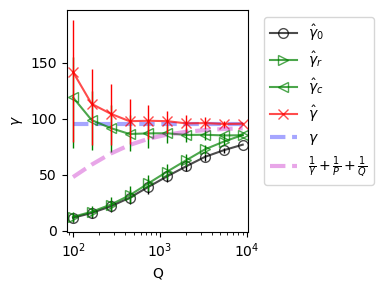

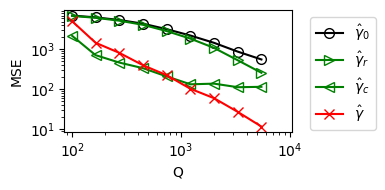

In [36]:

fig,ax=plt.subplots(1,1,figsize=(4,3))
fig2,ax2=plt.subplots(1,1,figsize=(4,2))

numer,denom=np.mean(Ass[-1,:,-1,0],axis=0), np.mean(Ass[-1,:,-1,1],axis=0)
gamma=numer/denom

ms=7

alpha=0.7

xoi=Qs


ls='-'
lw=1.5

colorvs=['k','g','g','r']
markers=['o','>','<','x']
labels=[r'$\hat{\gamma}_0$', r'$\hat{\gamma}_r$', r'$\hat{\gamma}_c$',r'$\hat{\gamma}$',r'$\hat{\gamma}$']
for i,(colorv,marker,label) in enumerate(zip(colorvs,markers,labels)):
    numer, denom = Ass[:,:,i,0], Ass[:,:,i,1]

    qoi=numer/denom #(num_so_Q_it/np.sqrt(de2_so_a_Q_it*de2_so_b_Q_it))[:,:,i,1]
    
    
    yval=np.nanmedian(qoi,axis=1)
    lower_error=np.nanquantile(qoi,axis=1,q=0.25)
    upper_error=np.nanquantile(qoi,axis=1,q=0.75)
    asymmetric_error = [yval-lower_error, upper_error-yval]
    #yval=np.mean(qoi,axis=1)
    asymmetric_error = [np.std(qoi,axis=1),np.std(qoi,axis=1)]
    ax.errorbar(xoi, yval, yerr=asymmetric_error,c=colorv,marker='',ls='',alpha=1,lw=1,zorder=0)#, fmt='o')
    yval=np.nanmean(qoi,axis=1)
    ax.plot(xoi, yval,c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label)#, fmt='o')

#ax.plot(xoi, np.mean(numer,axis=-1)/np.mean(denom,axis=-1),c=colorv)
    ax2.plot(xoi[:-1],np.mean(np.square(gamma-qoi),axis=1)[:-1], c=colorv,ms=ms,marker=marker,ls=ls,fillstyle='none',label=label)


ax.plot(xoi,xoi*0+gamma,c='b',ls='--',label=r'$\gamma$',zorder=-10,alpha=0.35,lw=3)
ax.plot(Qs,1/(1/Qs+1/P+1/gamma),c='m',ls='--',alpha=0.35,lw=3,label=r'$\frac{1}{\gamma} + \frac{1}{P} + \frac{1}{Q}$')

ax.set_xlabel('Q')
ax.set_xscale('log')
ax2.set_xlabel('Q')
ax2.set_xscale('log')
ax2.set_yscale('log')

ax.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])
ax2.set_xlim([np.min(Qs)*0.85, np.max(Qs)*1.15])

#ax.set_ylim([


ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

ax2.set_ylabel('MSE')
    #for q in range(100):
ax.set_ylabel(r'$\gamma$')

fig.tight_layout()
fig2.tight_layout()


fig.savefig("stringer_dim_Qs.pdf", bbox_inches='tight')
fig2.savefig("stringer_dim_mse_Qs.pdf", bbox_inches='tight')



In [4]:
from jax import random


key = random.PRNGKey(0)

M=np.shape(sresp[0])[0]
F=np.shape(sresp[0])[1]

Ps=np.power(10,np.linspace(np.log10(100),np.log10(M),10)).astype(int)
#Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
Q=F#F#2000

numit=100
Ass2=[]
for P in Ps:
    As=[]
    print(P)
    for i in range(numit):
        if P==M and i>=1:
            As.append(results)
            continue
        key_A, key = random.split(key)
        random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
        key_A, key = random.split(key)
        random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)# * sigma
        
        Theta1=sresp[0][random_indicesP,:][:,random_indicesQ]
        Theta2=sresp[1][random_indicesP,:][:,random_indicesQ] 
        results=[getest_all(Theta1,Theta2,P,Q)]
        As.append(results)
    Ass2.append(As)
Ass2=np.squeeze(np.array(Ass2))


2025-03-21 17:19:35.521427: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version (12.6.20). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


100
144
209
303
439
636
922
1335
1933
2800


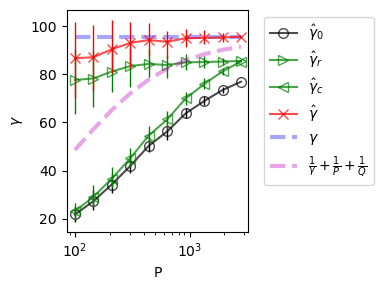

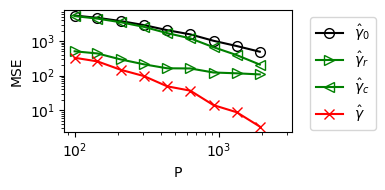

In [6]:

fig,ax=plt.subplots(1,1,figsize=(4,3))
fig2,ax2=plt.subplots(1,1,figsize=(4,2))

numer,denom=np.mean(Ass2[-1,:,-1,0],axis=0), np.mean(Ass2[-1,:,-1,1],axis=0)
gamma=numer/denom

ms=7

alpha=0.7

xoi=Ps


ls='-'
lw=1.5

colorvs=['k','g','g','r']
markers=['o','>','<','x']
labels=[r'$\hat{\gamma}_0$', r'$\hat{\gamma}_r$', r'$\hat{\gamma}_c$',r'$\hat{\gamma}$',r'$\hat{\gamma}$']
for i,(colorv,marker,label) in enumerate(zip(colorvs,markers,labels)):
    numer, denom = Ass2[:,:,i,0], Ass2[:,:,i,1]

    qoi=numer/denom #(num_so_Q_it/np.sqrt(de2_so_a_Q_it*de2_so_b_Q_it))[:,:,i,1]
    
    
    yval=np.nanmedian(qoi,axis=1)
    lower_error=np.nanquantile(qoi,axis=1,q=0.25)
    upper_error=np.nanquantile(qoi,axis=1,q=0.75)
    asymmetric_error = [yval-lower_error, upper_error-yval]
    #yval=np.mean(qoi,axis=1)
    asymmetric_error = [np.std(qoi,axis=1),np.std(qoi,axis=1)]
    ax.errorbar(xoi, yval, yerr=asymmetric_error,c=colorv,marker='',ls='',alpha=1,lw=1,zorder=0)#, fmt='o')
    yval=np.nanmean(qoi,axis=1)
    ax.plot(xoi, yval,c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label)#, fmt='o')

#ax.plot(xoi, np.mean(numer,axis=-1)/np.mean(denom,axis=-1),c=colorv)
    ax2.plot(xoi[:-1],np.mean(np.square(gamma-qoi),axis=1)[:-1], c=colorv,ms=ms,marker=marker,ls=ls,fillstyle='none',label=label)


ax.plot(xoi,xoi*0+gamma,c='b',ls='--',label=r'$\gamma$',zorder=-10,alpha=0.35,lw=3)
ax.plot(xoi,1/(1/xoi+1/Q+1/gamma),c='m',ls='--',alpha=0.35,lw=3,label=r'$\frac{1}{\gamma} + \frac{1}{P} + \frac{1}{Q}$')

ax.set_xlabel('P')
ax.set_xscale('log')
ax2.set_xlabel('P')
ax2.set_xscale('log')
ax2.set_yscale('log')

ax.set_xlim([np.min(Ps)*0.85, np.max(Ps)*1.15])
ax2.set_xlim([np.min(Ps)*0.85, np.max(Ps)*1.15])

#ax.set_ylim([


ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

ax2.set_ylabel('MSE')
    #for q in range(100):
ax.set_ylabel(r'$\gamma$')

fig.tight_layout()
fig2.tight_layout()


fig.savefig("stringer_dim_Ps.pdf", bbox_inches='tight')
fig2.savefig("stringer_dim_mse_Ps.pdf", bbox_inches='tight')

